In [1]:
# We assume that PyTorch is already installed
import torch
torchversion = torch.__version__

# Install PyTorch Scatter, PyTorch Sparse, and PyTorch Geometric
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-{torchversion}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-{torchversion}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

# Visualization
import networkx as nx
import matplotlib.pyplot as plt

# Others
from collections import defaultdict, deque, Counter
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected, remove_self_loops, to_networkx, degree
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import SAGEConv, GATv2Conv, GCNConv
import torch.nn.functional as F
from torch.nn import Linear, Dropout
import numpy as np
import pandas as pd




[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
d:\lightglue_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print(type(device))

True
1
NVIDIA RTX A5000
Using device: cuda
<class 'torch.device'>


In [3]:
wiki_topcats = r"C:\Users\Microtec\Downloads\wiki-topcats.txt"
wiki_topcats_categories = r"C:\Users\Microtec\Downloads\wiki-topcats-categories.txt"

# Load edge list
edges = pd.read_csv(
    wiki_topcats,
    sep=" ",
    comment="#",
    header=None,
    names=["src", "dst"]
)

edge_index = torch.tensor(
    edges.values.T,
    dtype=torch.long
)

edge_index, _ = remove_self_loops(edge_index)
edge_index = to_undirected(edge_index)

In [4]:
node_categories = defaultdict(list)
category_to_id = {}

with open(wiki_topcats_categories, "r", encoding="utf8") as f:
    for line in f:
        line = line.strip()

        if not line:
            continue

        category_part, nodes_part = line.split(";", 1)

        category = category_part.strip()

        if category not in category_to_id:
            category_to_id[category] = len(category_to_id)

        cat_id = category_to_id[category]

        nodes = nodes_part.strip().split()

        for node_str in nodes:
            node = int(node_str)
            node_categories[node].append(cat_id)

rows = []
cols = []

for node, cats in node_categories.items():
    for cat in cats:
        rows.append(node)
        cols.append(cat)

indices = torch.tensor(
    [rows, cols],
    dtype=torch.long
)

values = torch.ones(
    len(rows),
    dtype=torch.float32
)

num_nodes = max(
    edge_index.max().item(),
    max(node_categories.keys())
) + 1

#num_classes = len(category_to_id)
num_classes = 128

y = torch.sparse_coo_tensor(
    indices,
    values,
    (num_nodes, num_classes)
).coalesce()

x = torch.ones((num_nodes, 1), dtype=torch.float)

data = Data(
    x=x,
    edge_index=edge_index,
    y=y
)

data = data.to(device)

In [5]:
adj = defaultdict(list)

src = edge_index[0].tolist()
dst = edge_index[1].tolist()

for u, v in zip(src, dst):
    adj[u].append(v)
    adj[v].append(u)   # make graph undirected

def bfs_order(seed, adj):
    visited = set()
    order = []
    queue = deque([seed])

    while queue:
        node = queue.popleft()

        if node in visited:
            continue

        visited.add(node)
        order.append(node)

        for nbr in adj[node]:
            if nbr not in visited:
                queue.append(nbr)

    return order

order = bfs_order(0, adj)
print(len(order))

1791489


In [6]:
N = len(order)
train_end = int(0.70 * N)
val_end = int(0.85 * N)
train_seed = 0

train_nodes = order[:train_end]
val_nodes = order[train_end:val_end]
test_nodes = order[val_end:]

train_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

val_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

test_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

train_mask[list(train_nodes)] = True
val_mask[list(val_nodes)] = True
test_mask[list(test_nodes)] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

In [7]:
print("Dataset: Wiki-TopCats")
print("-------------------")
print("Number of graphs: 1")
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of features: {data.num_node_features}")
print(f"Number of classes: {num_classes}")

print("\nGraph:")
print("------")
print(f"Training nodes: {data.train_mask.sum().item()}")
print(f"Evaluation nodes: {data.val_mask.sum().item()}")
print(f"Test nodes: {data.test_mask.sum().item()}")
print(f"Edges are directed: {data.is_directed()}")
print(f"Graph has isolated nodes: {data.has_isolated_nodes()}")
print(f"Graph has loops: {data.has_self_loops()}")

# Multi-label specific information
print(f"Label memberships: {y._nnz()}")
print(f"Average labels per node: {y._nnz() / data.num_nodes:.2f}")

Dataset: Wiki-TopCats
-------------------
Number of graphs: 1
Number of nodes: 1791489
Number of features: 1
Number of classes: 128

Graph:
------
Training nodes: 1254042
Evaluation nodes: 268723
Test nodes: 268724
Edges are directed: False
Graph has isolated nodes: False
Graph has loops: False
Label memberships: 4716564
Average labels per node: 2.63


In [49]:
train_loader = NeighborLoader(
    data,
    num_neighbors=[35, 25],
    batch_size=1024,
    input_nodes=data.train_mask,
)

for i, subgraph in enumerate(train_loader):
    print(f"Subgraph {i}:")
    print(subgraph)

    if i == 0:
        break

Subgraph 0:
Data(x=[108433, 1], edge_index=[2, 168792], y=[108433, 128], train_mask=[108433], val_mask=[108433], test_mask=[108433], n_id=[108433], e_id=[168792], input_id=[1024], batch_size=1024)


In [50]:
print(subgraph.num_nodes, subgraph.num_edges)

108433 168792


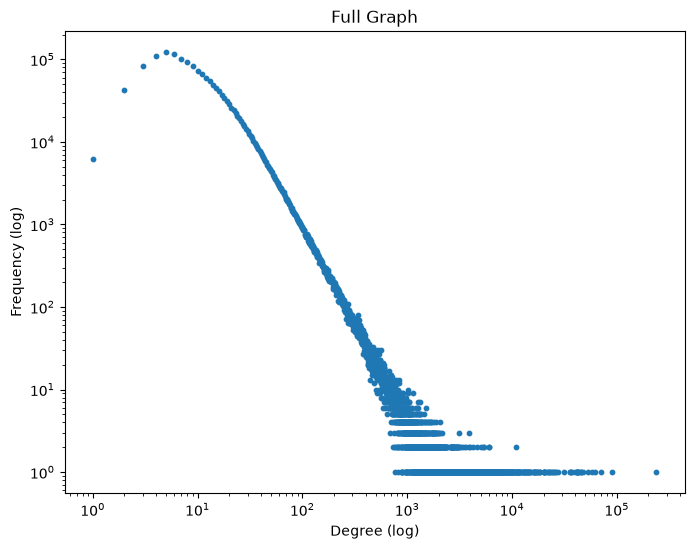

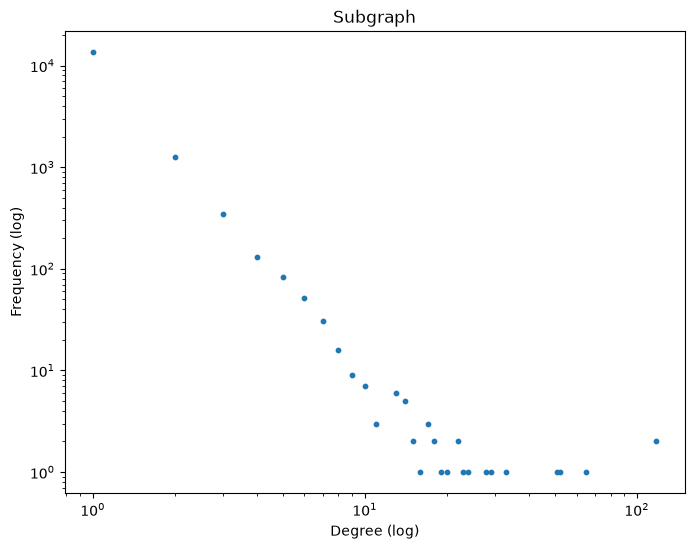

In [12]:
def plot_degree(data, title="Degree Distribution"):
    deg = degree(
        data.edge_index[0],
        num_nodes=data.num_nodes
    ).cpu().numpy()

    counts = Counter(deg)

    x = np.array(list(counts.keys()))
    y = np.array(list(counts.values()))

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, s=10)

    plt.xscale("log")
    plt.yscale("log")

    plt.title(title)
    plt.xlabel("Degree (log)")
    plt.ylabel("Frequency (log)")
    plt.show()


plot_degree(data, "Full Graph")
plot_degree(subdata, "Subgraph")

In [29]:
class GraphSAGE(torch.nn.Module):
    """
    GraphSAGE with differentiable community assignments.
    """

    def __init__(self,
                 dim_in,
                 dim_h,
                 num_communities=128):
        super().__init__()
        self.sage1 = SAGEConv(dim_in, dim_h)
        self.sage2 = SAGEConv(dim_h, num_communities)
        self.optimizer = torch.optim.Adam(
            self.parameters(),
            lr=0.01,
            weight_decay=5e-4
        )

    def forward(self, x, edge_index):
        h = self.sage1(x, edge_index)
        h = torch.relu(h)
        h = F.dropout(
            h,
            p=0.5,
            training=self.training
        )
        logits = self.sage2(h, edge_index)
        #
        # Soft module memberships
        #
        P = torch.softmax(
            logits,
            dim=1
        )
        return P

    def map_equation_loss(self,
                          P,
                          edge_index,
                          eps=1e-12):
        src = edge_index[0]
        dst = edge_index[1]
        # Community flow matrix
        flow = P[src].T @ P[dst]
        # Normalize flow
        flow = flow / (flow.sum() + eps)
        # Module visit probabilities
        p_module = flow.sum(dim=1)
        # Exit probabilities
        exit_flow = flow.sum(dim=1) - torch.diag(flow)
        q = exit_flow.sum()
        # Inter-module entropy
        if q > 0:
            q_dist = exit_flow / (q + eps)
            H_Q = -(
                q_dist *
                torch.log2(q_dist + eps)
            ).sum()
        else:
            H_Q = 0.0
        # Intra-module entropy
        H_P = 0.0
        K = flow.shape[0]
        for k in range(K):
            p_k = p_module[k]
            if p_k <= eps:
                continue
            module_flow = flow[k]
            module_dist = module_flow / (
                module_flow.sum() + eps
            )
            entropy = -(
                module_dist *
                torch.log2(module_dist + eps)
            ).sum()
            H_P += p_k * entropy
        # Map Equation
        L = q * H_Q + H_P
        return L

    def fit(self,
            data,
            epochs):
        
        train_loader = NeighborLoader(
            data,
            num_neighbors=[15,10],
            batch_size=1024,
            input_nodes=data.train_mask
        )
        optimizer = self.optimizer
        self.train()
        for epoch in range(epochs + 1):
            total_loss = 0.0
            total_active = 0
            for batch in train_loader:
                batch = batch.to(device)
                optimizer.zero_grad()
                P = self(
                    batch.x,
                    batch.edge_index
                )
                map_loss = self.map_equation_loss(
                    P,
                    batch.edge_index
                )
                community_usage = P.mean(dim=0)
                balance_loss = -(
                    community_usage *
                    torch.log(community_usage + 1e-12)
                ).sum()
                loss = map_loss - 0 * balance_loss
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
                
                community_usage = P.mean(dim=0)
                active_communities = (
                    community_usage > 1e-3
                ).sum().item()

                total_active += active_communities

            if epoch % 1 == 0:
                print(
                    f"Epoch {epoch:>3} | "
                    f"Map Equation Loss: "
                    f"{total_loss / len(train_loader):.6f} | "
                    f"Active Communities: {total_active/len(train_loader):.1f}"
                )
            
def accuracy(pred_y, y):
    """Calculate accuracy."""
    pred = (torch.sigmoid(pred_y) > 0.5).float()
    return (pred == y).float().mean()

def test(model, data):
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        out = model(
            data.x,
            data.edge_index
        )
    return out

In [51]:
%%time
# Create GraphSAGE
graphsage = GraphSAGE(data.num_features, 64, num_classes).to(device)
print(graphsage)

# Train
graphsage.fit(subgraph, 10)

# Test
#print(f'\nGraphSAGE test accuracy: {test(graphsage, data)*100:.2f}%\n')

GraphSAGE(
  (sage1): SAGEConv(1, 64, aggr=mean)
  (sage2): SAGEConv(64, 128, aggr=mean)
)
Epoch   0 | Map Equation Loss: 0.911499 | Active Communities: 25.3
Epoch   1 | Map Equation Loss: 0.230421 | Active Communities: 2.9
Epoch   2 | Map Equation Loss: 0.000004 | Active Communities: 2.0
Epoch   3 | Map Equation Loss: 0.000013 | Active Communities: 2.0
Epoch   4 | Map Equation Loss: 0.000017 | Active Communities: 2.0
Epoch   5 | Map Equation Loss: 0.000042 | Active Communities: 2.0
Epoch   6 | Map Equation Loss: 0.000080 | Active Communities: 2.0
Epoch   7 | Map Equation Loss: 0.000147 | Active Communities: 2.0
Epoch   8 | Map Equation Loss: 0.000296 | Active Communities: 2.0
Epoch   9 | Map Equation Loss: 0.000434 | Active Communities: 2.0
Epoch  10 | Map Equation Loss: 0.000569 | Active Communities: 2.0
CPU times: total: 2min 39s
Wall time: 43.7 s


In [52]:
graphsage.eval()

with torch.no_grad():
    P = graphsage(
        subdata.x.to(device),
        subdata.edge_index.to(device)
    )

community_distribution = P.mean(dim=0)

print(community_distribution)

tensor([1.7640e-07, 1.9366e-07, 1.9329e-07, 1.9331e-07, 1.9438e-07, 1.9534e-07,
        2.2477e-07, 1.7257e-07, 2.6497e-07, 1.9391e-07, 1.9276e-07, 1.7607e-07,
        2.0710e-07, 1.9495e-07, 1.6596e-07, 1.9200e-07, 1.9536e-07, 1.9537e-07,
        1.8240e-07, 1.9221e-07, 1.9623e-07, 1.8460e-07, 2.0312e-07, 3.3805e-07,
        1.9455e-07, 2.2448e-07, 1.9353e-07, 1.7136e-07, 1.8019e-07, 1.8973e-07,
        1.9254e-07, 1.9353e-07, 1.7456e-07, 1.9453e-07, 1.7684e-07, 1.9557e-07,
        1.9251e-07, 1.8100e-07, 1.9308e-07, 1.9433e-07, 1.7192e-07, 1.9360e-07,
        1.9289e-07, 1.7250e-07, 1.9374e-07, 1.9365e-07, 1.7228e-07, 1.8181e-07,
        1.7224e-07, 1.7710e-07, 1.9411e-07, 1.9255e-07, 1.9507e-07, 1.7727e-07,
        1.9298e-07, 1.9355e-07, 1.9387e-07, 1.8011e-07, 1.9360e-07, 1.9588e-07,
        1.8931e-07, 1.9550e-07, 1.9501e-07, 1.7027e-07, 1.9251e-07, 1.9181e-07,
        1.9357e-07, 1.9307e-07, 1.9334e-07, 1.9361e-07, 1.7935e-07, 1.9272e-07,
        1.8864e-07, 1.9339e-07, 1.9421e-

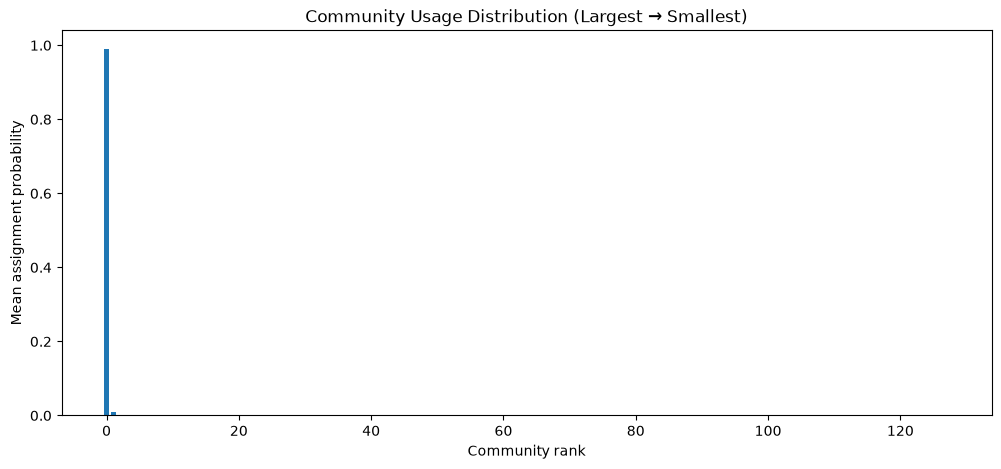

In [53]:
community_usage = P.mean(dim=0).detach().cpu()

# Sort descending
sorted_usage, _ = torch.sort(
    community_usage,
    descending=True
)

plt.figure(figsize=(12, 5))
plt.bar(
    range(len(sorted_usage)),
    sorted_usage.numpy()
)

plt.xlabel("Community rank")
plt.ylabel("Mean assignment probability")
plt.title("Community Usage Distribution (Largest → Smallest)")
plt.show()


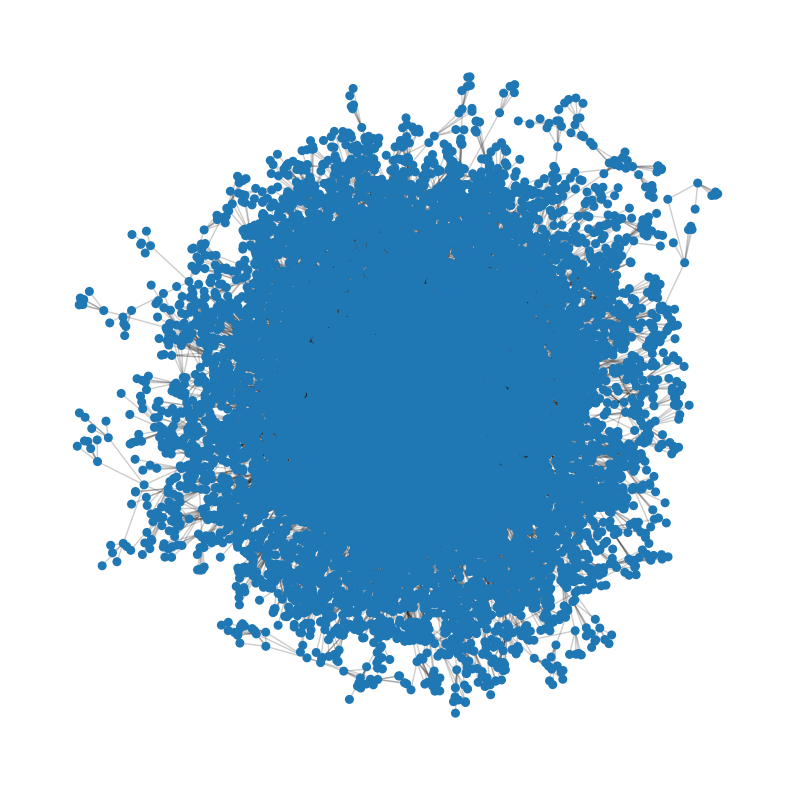

In [102]:
graphsage.eval()

with torch.no_grad():
    P = graphsage(
        subgraph.x,
        subgraph.edge_index
    )

communities = P.argmax(dim=1)

G = to_networkx(
    subgraph,
    to_undirected=True
)

plt.figure(figsize=(10,10))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=30,
    node_color=communities.cpu(),
    cmap="tab20"
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2
)

plt.axis("off")
plt.show()

## Planetoid

In [103]:
import torch
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root='.', name="Pubmed")
data = dataset[0]

# Print information about the dataset
print(f'Dataset: {dataset}')
print('-------------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {data.x.shape[0]}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Print information about the graph
print(f'\nGraph:')
print('------')
print(f'Training nodes: {sum(data.train_mask).item()}')
print(f'Evaluation nodes: {sum(data.val_mask).item()}')
print(f'Test nodes: {sum(data.test_mask).item()}')
print(f'Edges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')

Processing...
d:\lightglue_env\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
d:\lightglue_env\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
d:\lightglue_env\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
d:\lightglue_env\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWa

Dataset: Pubmed()
-------------------
Number of graphs: 1
Number of nodes: 19717
Number of features: 500
Number of classes: 3

Graph:
------
Training nodes: 60
Evaluation nodes: 500
Test nodes: 1000
Edges are directed: False
Graph has isolated nodes: False
Graph has loops: False


Subgraph 0: Data(x=[411, 500], edge_index=[2, 463], y=[411], train_mask=[411], val_mask=[411], test_mask=[411], n_id=[411], e_id=[463], input_id=[16], batch_size=16)
Subgraph 1: Data(x=[262, 500], edge_index=[2, 311], y=[262], train_mask=[262], val_mask=[262], test_mask=[262], n_id=[262], e_id=[311], input_id=[16], batch_size=16)
Subgraph 2: Data(x=[269, 500], edge_index=[2, 313], y=[269], train_mask=[269], val_mask=[269], test_mask=[269], n_id=[269], e_id=[313], input_id=[16], batch_size=16)
Subgraph 3: Data(x=[198, 500], edge_index=[2, 229], y=[198], train_mask=[198], val_mask=[198], test_mask=[198], n_id=[198], e_id=[229], input_id=[12], batch_size=12)


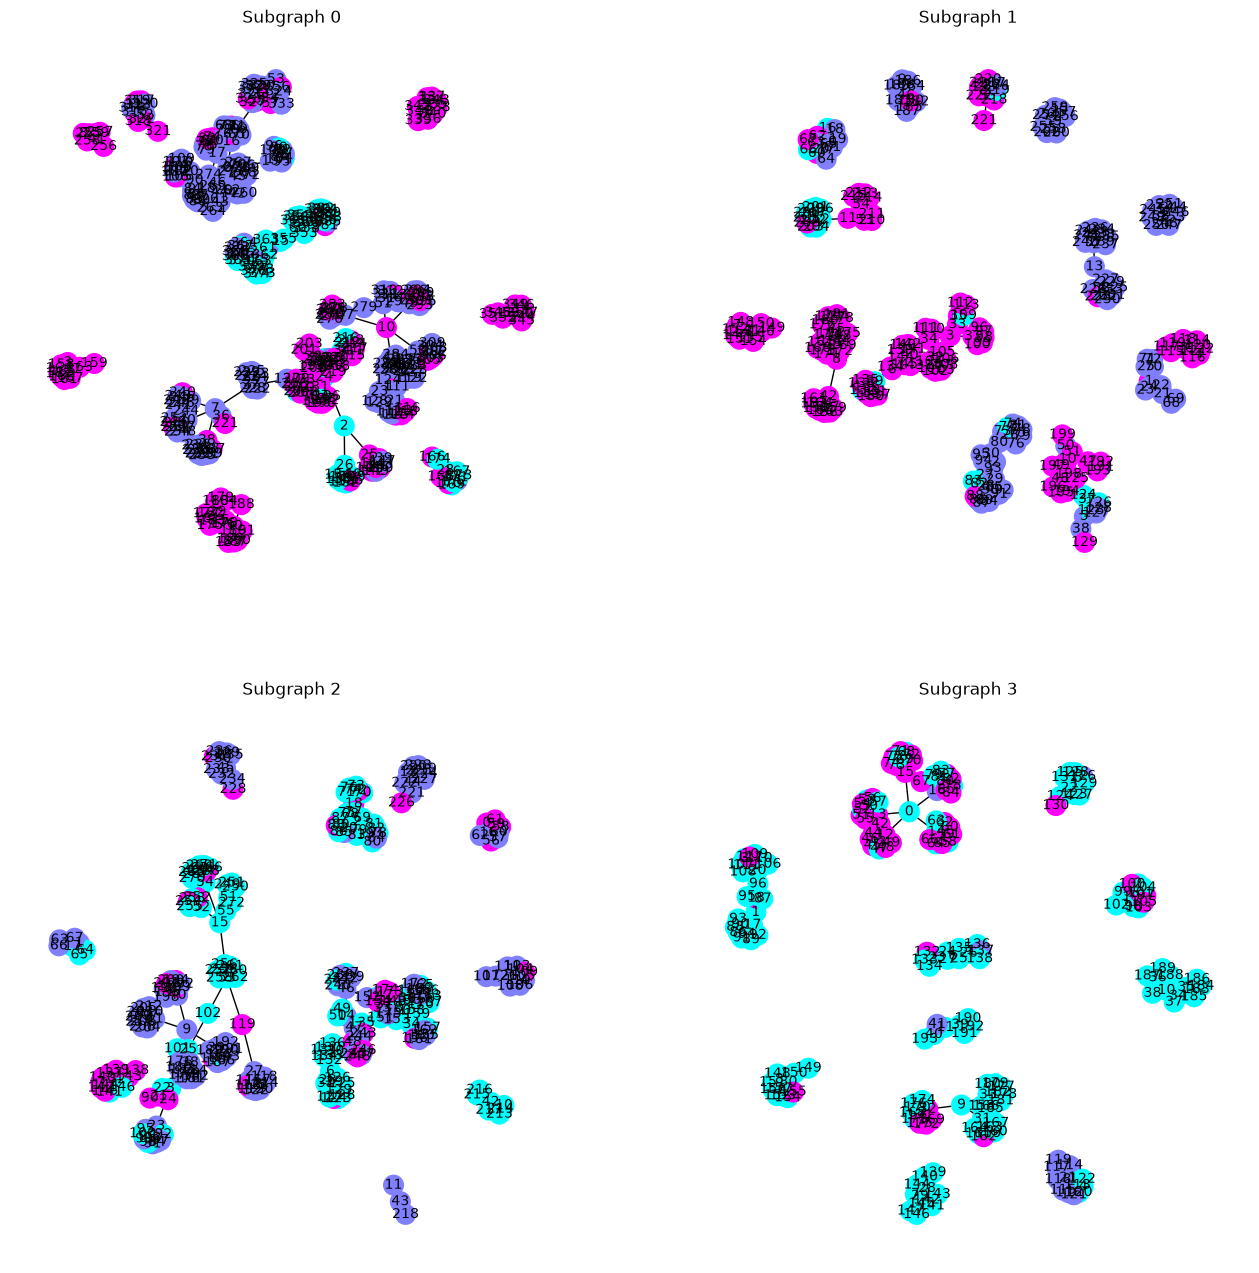

In [105]:
# Create batches with neighbor sampling
train_loader = NeighborLoader(
    data,
    num_neighbors=[5, 10],
    batch_size=16,
    input_nodes=data.train_mask,
)

# Print each subgraph
for i, subgraph in enumerate(train_loader):
    print(f'Subgraph {i}: {subgraph}')

# Plot each subgraph
fig = plt.figure(figsize=(16,16))
for idx, (subdata, pos) in enumerate(zip(train_loader, [221, 222, 223, 224])):
    G = to_networkx(subdata, to_undirected=True)
    ax = fig.add_subplot(pos)
    ax.set_title(f'Subgraph {idx}')
    plt.axis('off')
    nx.draw_networkx(G,
                    pos=nx.spring_layout(G, seed=0),
                    with_labels=True,
                    node_size=200,
                    node_color=subdata.y,
                    cmap="cool",
                    font_size=10
                    )
plt.show()

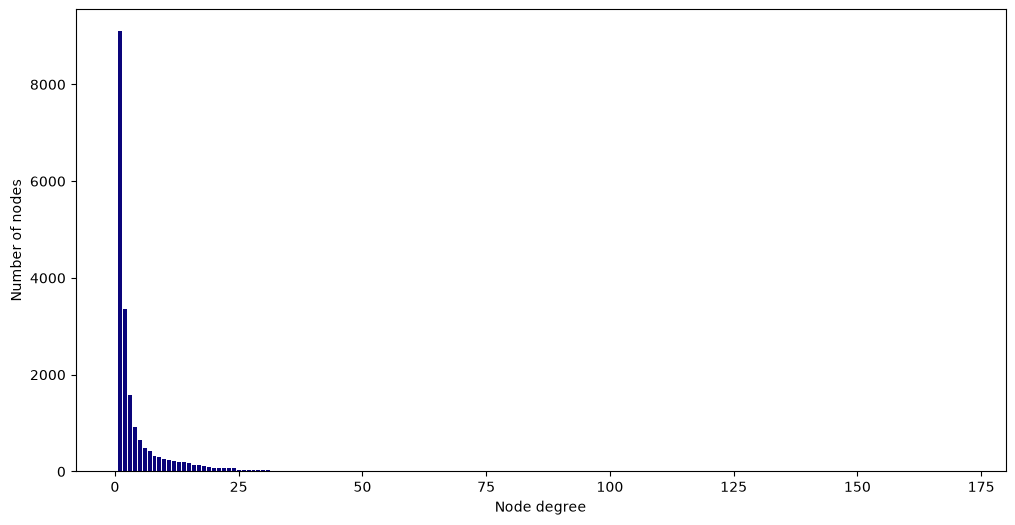

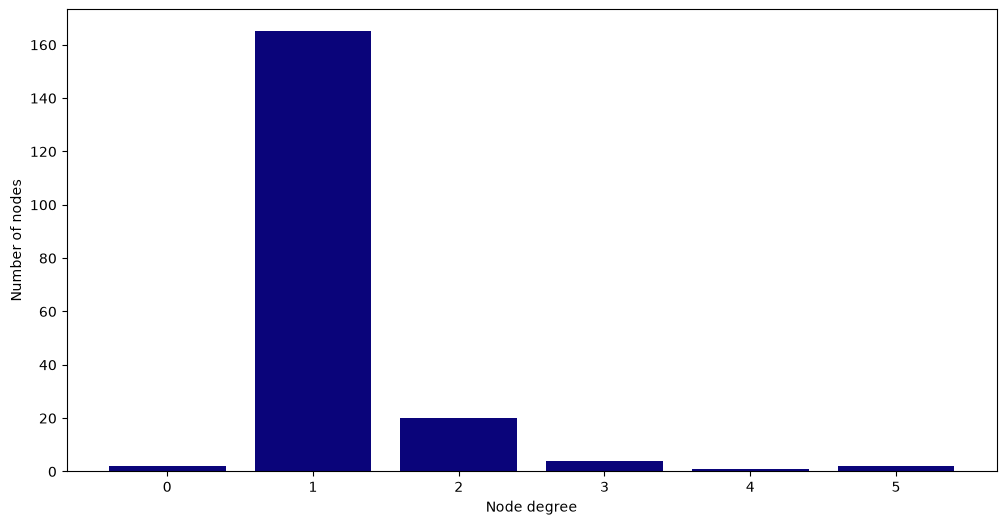

In [106]:
from torch_geometric.utils import degree
from collections import Counter

def plot_degree(data):
  # Get list of degrees for each node
  degrees = degree(data.edge_index[0]).numpy()

  # Count the number of nodes for each degree
  numbers = Counter(degrees)

  # Bar plot
  fig, ax = plt.subplots(figsize=(12, 6))
  ax.set_xlabel('Node degree')
  ax.set_ylabel('Number of nodes')
  plt.bar(numbers.keys(),
          numbers.values(),
          color='#0A047A')

# Plot node degrees from the original graph
plot_degree(data)

# Plot node degrees from the last subgraph
plot_degree(subdata)

In [113]:
%%time
# Create GraphSAGE
graphsage = GraphSAGE(dataset.num_features, 64, dataset.num_classes).to(device)
print(graphsage)

# Train
graphsage.fit(data, 20)

# Test
print(f'\nGraphSAGE test accuracy: {test(graphsage, data)*100:.2f}%\n')

GraphSAGE(
  (sage1): SAGEConv(500, 64, aggr=mean)
  (sage2): SAGEConv(64, 3, aggr=mean)
)
Epoch   0 | Map Equation Loss: 2.640078 | Active Communities: 3.0
Epoch   1 | Map Equation Loss: 2.627143 | Active Communities: 3.0
Epoch   2 | Map Equation Loss: 2.592787 | Active Communities: 3.0
Epoch   3 | Map Equation Loss: 2.521671 | Active Communities: 3.0
Epoch   4 | Map Equation Loss: 2.386653 | Active Communities: 3.0
Epoch   5 | Map Equation Loss: 2.143533 | Active Communities: 3.0
Epoch   6 | Map Equation Loss: 1.844908 | Active Communities: 3.0
Epoch   7 | Map Equation Loss: 1.424512 | Active Communities: 3.0
Epoch   8 | Map Equation Loss: 1.008699 | Active Communities: 3.0
Epoch   9 | Map Equation Loss: 0.631573 | Active Communities: 3.0
Epoch  10 | Map Equation Loss: 0.382013 | Active Communities: 3.0
Epoch  11 | Map Equation Loss: 0.208336 | Active Communities: 3.0
Epoch  12 | Map Equation Loss: 0.128292 | Active Communities: 3.0
Epoch  13 | Map Equation Loss: 0.077461 | Active Co

TypeError: unsupported format string passed to Tensor.__format__

In [112]:

result = test(graphsage, data)
print(result)


tensor([[1.7163e-05, 9.3060e-10, 9.9998e-01],
        [1.9266e-05, 1.1797e-09, 9.9998e-01],
        [8.5020e-06, 2.4755e-10, 9.9999e-01],
        ...,
        [2.0835e-05, 1.3789e-09, 9.9998e-01],
        [5.7461e-06, 1.2389e-10, 9.9999e-01],
        [1.1917e-05, 4.9897e-10, 9.9999e-01]], device='cuda:0')


In [114]:
pred = result.argmax(dim=1)

print(pred)
print(torch.bincount(pred))

tensor([2, 2, 2,  ..., 2, 2, 2], device='cuda:0')
tensor([    0,     0, 19717], device='cuda:0')
